In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
# Reusable plotting function
def plot_svm(model, X, y, title, ax):
    # Create a mesh covering the feature space
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.decision_function(grid).reshape(xx.shape)

    # Decision regions and boundaries
    ax.contourf(xx, yy, Z > 0, alpha=0.15, cmap=plt.cm.coolwarm)
    ax.contour(
        xx, yy, Z,
        levels=[-1, 0, 1],
        colors=["gray", "black", "gray"],
        linestyles=["--", "-", "--"],
        linewidths=[1, 2, 1]
    )

    # Data points
    ax.scatter(
        X[:, 0], X[:, 1],
        c=y, cmap=plt.cm.coolwarm,
        edgecolors="k", s=35
    )

    # Support vectors
    svc = model.named_steps["svc"]
    support_vectors = model.named_steps["standardscaler"].inverse_transform(
        svc.support_vectors_
    )

    ax.scatter(
        support_vectors[:, 0], support_vectors[:, 1],
        s=150, facecolors="none", edgecolors="green",
        linewidths=1.8, label="Support vectors"
    )

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()

# 1. HARD-MARGIN SVM

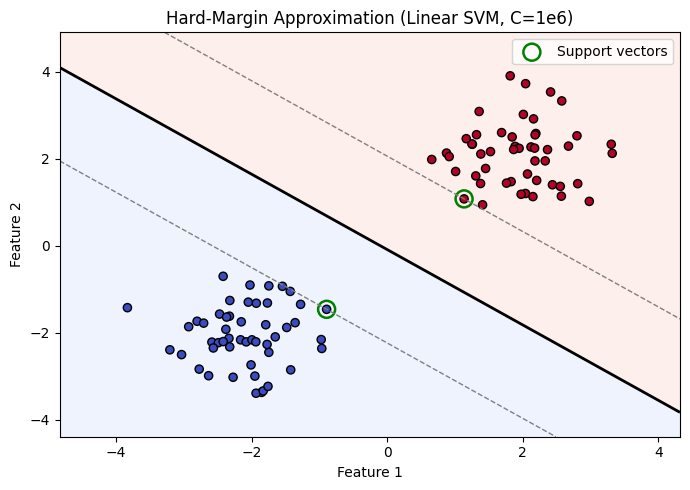

In [3]:
# Create linearly separable data using scikit-learn
X_hard, y_hard = make_blobs(
    n_samples=100,
    centers=[[-2, -2], [2, 2]],
    cluster_std=0.7,
    random_state=42
)

# Very large C approximates hard-margin SVM
hard_margin_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=1e6)
)

hard_margin_model.fit(X_hard, y_hard)

fig, ax = plt.subplots(figsize=(7, 5))
plot_svm(
    hard_margin_model, X_hard, y_hard,
    "Hard-Margin Approximation (Linear SVM, C=1e6)", ax
)
plt.tight_layout()
plt.show()



# SOFT-MARGIN SVM: EFFECT OF C

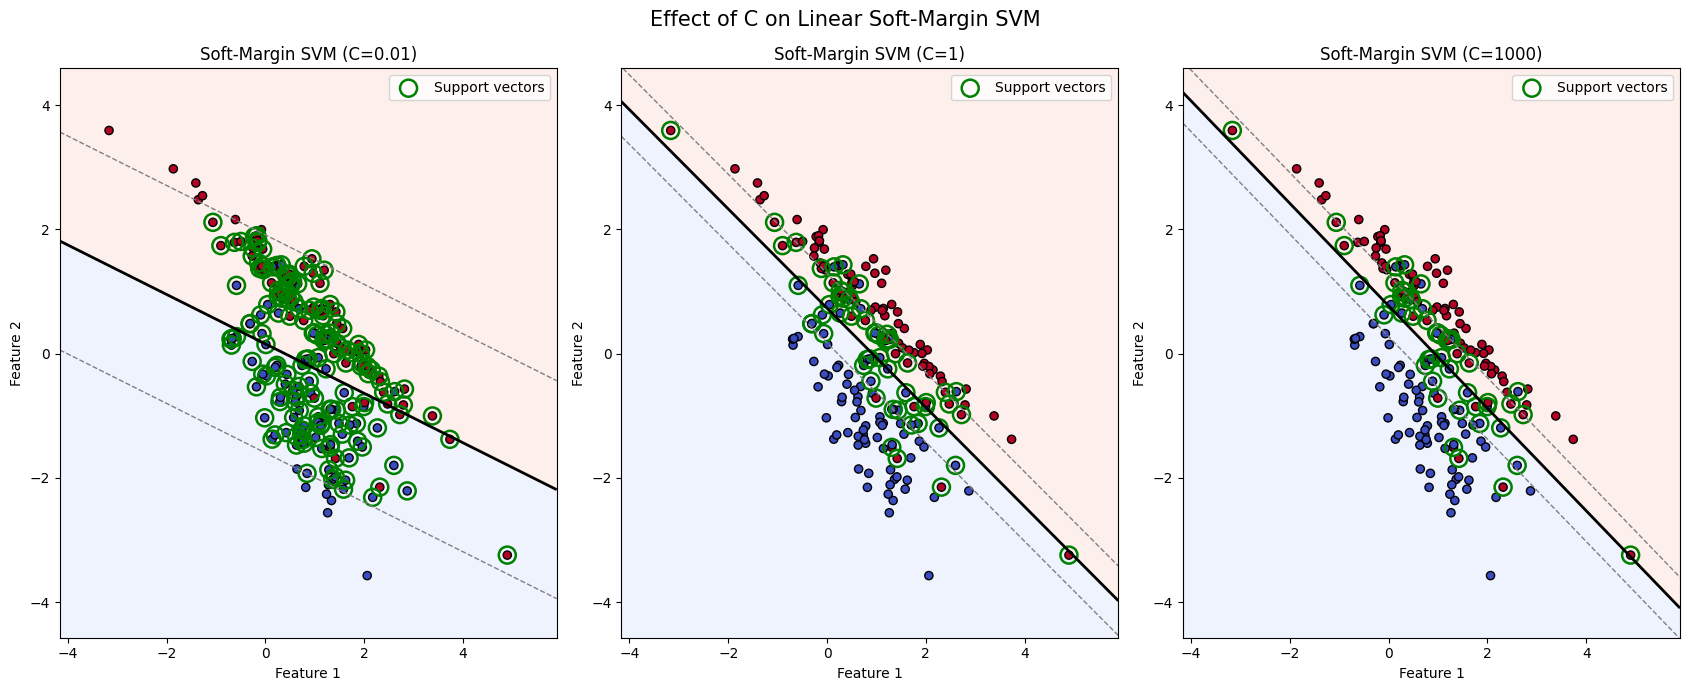

In [5]:
# Create a dataset with overlap/noise
X_soft, y_soft = make_classification(
    n_samples=180,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.8,
    flip_y=0.12,
    random_state=42
)

C_values = [0.01, 1, 1000]

fig, axes = plt.subplots(1, 3, figsize=(17, 7))

for ax, C in zip(axes, C_values):
    soft_model = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=C)
    )

    soft_model.fit(X_soft, y_soft)

    plot_svm(
        soft_model, X_soft, y_soft,
        f"Soft-Margin SVM (C={C})", ax
    )

plt.suptitle("Effect of C on Linear Soft-Margin SVM", fontsize=15)
plt.tight_layout()
plt.show()


# 3. NONLINEAR SVM: POLYNOMIAL KERNEL

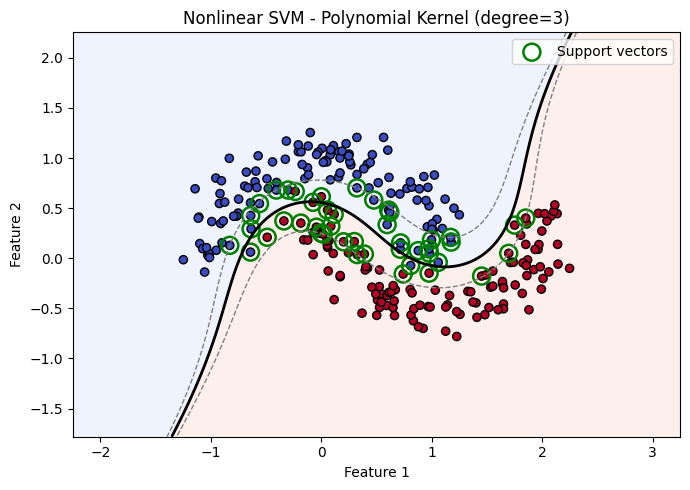

In [6]:
# Two-moons dataset is useful for nonlinear classification
X_moons, y_moons = make_moons(
    n_samples=250,
    noise=0.15,
    random_state=42
)

poly_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="poly", degree=3, C=1, coef0=1)
)

poly_model.fit(X_moons, y_moons)

fig, ax = plt.subplots(figsize=(7, 5))
plot_svm(
    poly_model, X_moons, y_moons,
    "Nonlinear SVM - Polynomial Kernel (degree=3)", ax
)
plt.tight_layout()
plt.show()


# 4. NONLINEAR SVM: RBF KERNEL

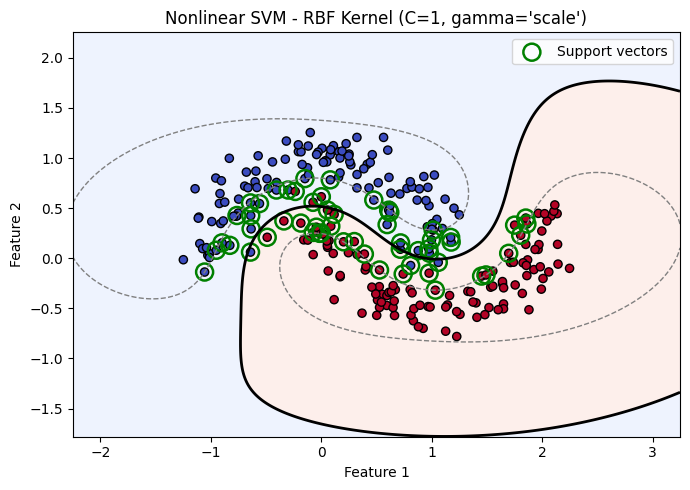

In [7]:
rbf_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=1, gamma="scale")
)

rbf_model.fit(X_moons, y_moons)

fig, ax = plt.subplots(figsize=(7, 5))
plot_svm(
    rbf_model, X_moons, y_moons,
    "Nonlinear SVM - RBF Kernel (C=1, gamma='scale')", ax
)
plt.tight_layout()
plt.show()